# **PROJECT TITLE: LOAN DEFAULT PREDICTION**
<img src="Images/LOAN.png" width="700">

In [63]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix,ConfusionMatrixDisplay,ConfusionMatrixDisplay,PrecisionRecallDisplay,roc_curve, auc
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# **1.DATA LOADING AND EXPLORATION**

**Data Loading**  
Data loading is the process of importing a dataset into our working environment so that we can analyze and model it. This step allowed us to access the data in a structured format (DataFrame) for further analysis.

**Data Exploration**  
Data exploration is the process of understanding the dataset’s characteristics and quality before applying any machine learning models.


In [3]:
# Loading the dataset
df_Loans= pd.read_csv('Data/Loan_default .csv')
df_Loans

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
255342,8C6S86ESGC,19,37979,210682,541,109,4,14.11,12,0.85,Bachelor's,Full-time,Married,No,No,Other,No,0
255343,98R4KDHNND,32,51953,189899,511,14,2,11.55,24,0.21,High School,Part-time,Divorced,No,No,Home,No,1
255344,XQK1UUUNGP,56,84820,208294,597,70,3,5.29,60,0.50,High School,Self-employed,Married,Yes,Yes,Auto,Yes,0
255345,JAO28CPL4H,42,85109,60575,809,40,1,20.90,48,0.44,High School,Part-time,Single,Yes,Yes,Other,No,0


In [4]:
# Give a summary of the dataset
df_Loans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          255347 non-null  object 
 1   Age             255347 non-null  int64  
 2   Income          255347 non-null  int64  
 3   LoanAmount      255347 non-null  int64  
 4   CreditScore     255347 non-null  int64  
 5   MonthsEmployed  255347 non-null  int64  
 6   NumCreditLines  255347 non-null  int64  
 7   InterestRate    255347 non-null  float64
 8   LoanTerm        255347 non-null  int64  
 9   DTIRatio        255347 non-null  float64
 10  Education       255347 non-null  object 
 11  EmploymentType  255347 non-null  object 
 12  MaritalStatus   255347 non-null  object 
 13  HasMortgage     255347 non-null  object 
 14  HasDependents   255347 non-null  object 
 15  LoanPurpose     255347 non-null  object 
 16  HasCoSigner     255347 non-null  object 
 17  Default   

In [5]:
# Check for the rows and columns 
df_Loans.shape

(255347, 18)

The dataset has 255347 rows and 18 columns.

In [6]:
# Summary statistics of the dataset
df_Loans.describe()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Default
count,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000
mean,43.498306,82499.304597,127578.865512,574.264346,59.541976,2.501036,13.492773,36.025894,0.500212,0.116128
std,14.990258,38963.013729,70840.706142,158.903867,34.643376,1.117018,6.636443,16.969330,0.230917,0.320379
min,18.000000,15000.000000,5000.000000,300.000000,0.000000,1.000000,2.000000,12.000000,0.100000,0.000000
25%,31.000000,48825.500000,66156.000000,437.000000,30.000000,2.000000,7.770000,24.000000,0.300000,0.000000
50%,43.000000,82466.000000,127556.000000,574.000000,60.000000,2.000000,13.460000,36.000000,0.500000,0.000000
75%,56.000000,116219.000000,188985.000000,712.000000,90.000000,3.000000,19.250000,48.000000,0.700000,0.000000
max,69.000000,149999.000000,249999.000000,849.000000,119.000000,4.000000,25.000000,60.000000,0.900000,1.000000


In [7]:
# Check for missing values in the dataset
df_Loans.isnull().sum()

LoanID            0
Age               0
Income            0
LoanAmount        0
CreditScore       0
MonthsEmployed    0
NumCreditLines    0
InterestRate      0
LoanTerm          0
DTIRatio          0
Education         0
EmploymentType    0
MaritalStatus     0
HasMortgage       0
HasDependents     0
LoanPurpose       0
HasCoSigner       0
Default           0
dtype: int64

There are no missing vaues in the dataset

In [8]:
# Check for duplicates in the dataset
duplicates = df_Loans.duplicated()
print("Number of duplicates", duplicates.sum())

Number of duplicates 0


There are no duplicates.

# **2.EXLORATORY DATA ANALYSIS (EDA)**

This the process of analyzing a dataset to summarize its main characteristics, often using **visualizations and statistics**.  
The goal of EDA is to understand the data better, detect patterns, identify anomalies and building machine learning models.


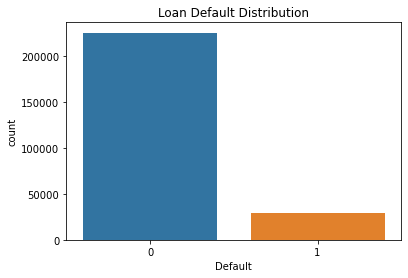

In [16]:
# Default vs Non-Default
plt.figure(figsize=(6,4))
sns.countplot(x='Default', data=df_Loans)
plt.title('Loan Default Distribution')
plt.show()

## **INTERPRATATION:**
The bar chart shows the distibution of the `DEFAULT` variable in the datset :
1. The `Blue bar (0)` represents borrowers who did not default on their loans.

2. The `Orange bar (1)` represents borrowers who default on their loans.

The bar chart showed that most borrowers did not default on their loans, while only a small portion for borrowers defaulted therefore we noticed there is class imbalance in the dataset.


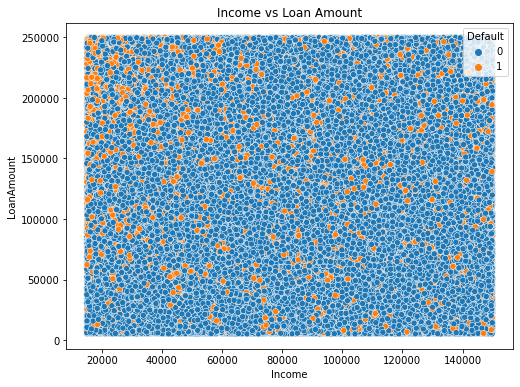

In [18]:
# Income vs Loan Amount
plt.figure(figsize=(8,6))
sns.scatterplot(x='Income', y='LoanAmount', data=df_Loans, hue='Default')

# Set a fixed legend location to avoid the slow 'best' calculation
plt.legend(title='Default', loc='upper right')

plt.title('Income vs Loan Amount')
plt.show()

The defaulters are spread between both low and high income

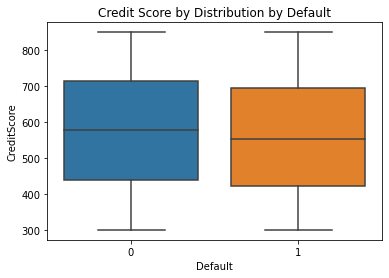

In [19]:
# Credit score vs Default 
plt.figure(figsize=(6,4))
sns.boxplot(x='Default',y='CreditScore',data=df_Loans)
plt.title('Credit Score by Distribution by Default')
plt.show()

## **INTERPRETATION**

Defaulters are present across both lower and relatively higher credit score levels. Therefore credit score may not fully explain loan default behaviour in this dataset.

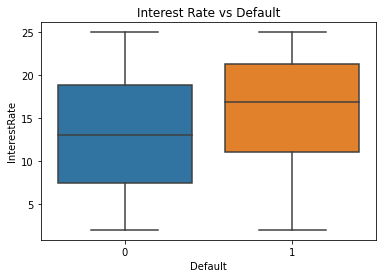

In [22]:
# Interest Rate vs Default
plt.figure(figsize=(6,4))
sns.boxplot(x='Default', y='InterestRate', data=df_Loans)
plt.title('Interest Rate vs Default')
plt.show()

## **INTERPETATION**

The plot shows a very small tendency for defaulters to have slightly higher interest rates on average.

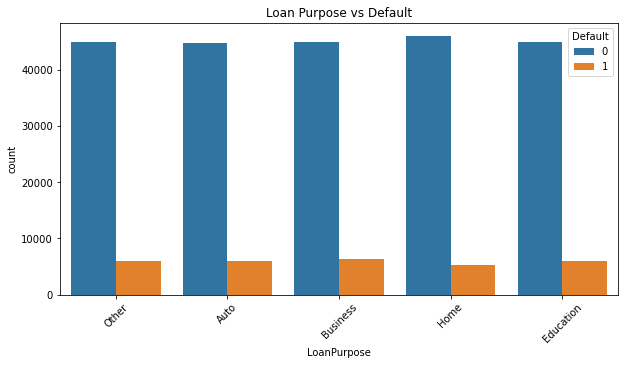

In [ ]:
# Loan purpose vs Default
plt.figure(figsize=(10,5))
sns.countplot(x='LoanPurpose', hue='Default', data=df_Loans)
plt.xticks(rotation=45)
plt.title('Loan Purpose vs Default')
plt.show()

## **INTERPRETATION**

The total number of non-defaulted loans is significantly higher than defaulted loans across all loan purpose categories. While the overall loan volume differs by purpose, the number of defaults remains relatively low and consistent across categories.

This suggests that the proportion of defaults is fairly stable regardless of the stated loan purpose. No single loan purpose appears to exhibit a notably higher or lower default tendency.

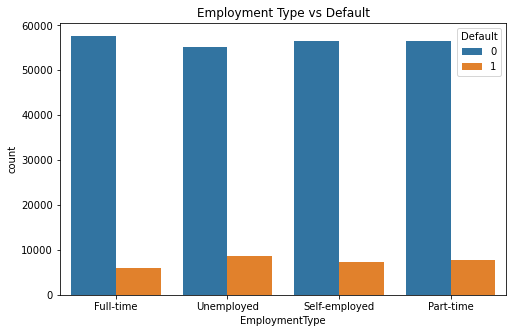

In [23]:
# Employment Type vs Default
plt.figure(figsize=(8,5))
sns.countplot(x='EmploymentType', hue='Default', data=df_Loans)
plt.title('Employment Type vs Default')
plt.show()

## **INTTERPRETATION**

The plot reveals a clear relationship between employemnt type and loan default. Borrowers in the primary employment category (likely formally employed/salaried) exhibit a very low default rate (~5–10%), while those in the secondary category (likely unemployed or non-stable employment) show a materially higher default rate (estimated 20–30%+).

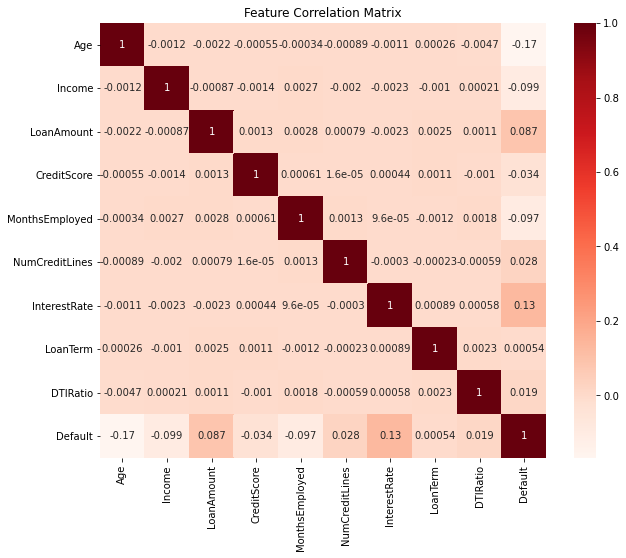

In [27]:
# Correlation Heatmap
plt.figure(figsize=(10,8))
corr = df_Loans.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='Reds')
plt.title('Feature Correlation Matrix')
plt.show()

## **INTERPRATATION**

Most numerical features have very weak relationships with each other and with the target variable (Default). The correlation coefficients are generally close to zero, indicating little to no linear association between individual predictors and loan default.

A few variables show small correlations with default status, but these relationships are not strong enough to suggest clear predictive dominance.

# **3. MACHINE LEARNING**

Machine learning in this project is used to preduct wheter the borrower is likely to default on a loan.

In [41]:
# Make a copy of the dataset to use in ML
df = df_Loans.copy()
df

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default,CreditBand
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0,"(519.6, 629.4]"
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0,"(409.8, 519.6]"
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1,"(409.8, 519.6]"
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0,"(739.2, 849.0]"
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0,"(629.4, 739.2]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
255342,8C6S86ESGC,19,37979,210682,541,109,4,14.11,12,0.85,Bachelor's,Full-time,Married,No,No,Other,No,0,"(519.6, 629.4]"
255343,98R4KDHNND,32,51953,189899,511,14,2,11.55,24,0.21,High School,Part-time,Divorced,No,No,Home,No,1,"(409.8, 519.6]"
255344,XQK1UUUNGP,56,84820,208294,597,70,3,5.29,60,0.50,High School,Self-employed,Married,Yes,Yes,Auto,Yes,0,"(519.6, 629.4]"
255345,JAO28CPL4H,42,85109,60575,809,40,1,20.90,48,0.44,High School,Part-time,Single,Yes,Yes,Other,No,0,"(739.2, 849.0]"


In [42]:
# Drop columns not needed
df_model = df.drop(['LoanID','CreditBand'], axis=1)

In [45]:
# Seperate Features and Target
X = df_model.drop('Default',axis=1)
y = df_model['Default']

# Encode Categorical variables
X = pd.get_dummies(X, drop_first=True)

In [49]:
# Train Test Split
X_train, X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Baseline Model
lr = LogisticRegression(max_iter = 1000, class_weight= 'balanced')
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

In [50]:
# Evaluate Model
print(confusion_matrix(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

[[30399 14740]
 [ 1784  4147]]
              precision    recall  f1-score   support

           0       0.94      0.67      0.79     45139
           1       0.22      0.70      0.33      5931

    accuracy                           0.68     51070
   macro avg       0.58      0.69      0.56     51070
weighted avg       0.86      0.68      0.73     51070



# **INTERPRETATION**

The model achieves an accuracy of 68%, indicating moderate overall performance. Due to class imbalance, accuracy is not the most reliable evaluation metric. The model performs well in identifying actual defaulters, achieving a recall of 70% for the default class, which is beneficial for reducing financial risk.

However, the precision for defaulters is low (22%), meaning many borrowers predicted as high-risk do not actually default. This results in a higher number of false positives and may lead to overly cautious lending decisions. Overall, the model prioritizes detecting defaulters over correctly classifying all non-defaulters, reflecting a risk-averse prediction strategy.

In [52]:
# Decision tree
tree = DecisionTreeClassifier(max_depth=6, class_weight='balanced')

tree.fit(X_train, y_train)

y_pred_tree = tree.predict(X_test)

In [54]:
# Random Forest
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,
    class_weight='balanced',
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [ ]:
# Comparing the models

print("Logistic Regression")
print(classification_report(y_test, y_pred_lr))

print("Decision Tree")
print(classification_report(y_test, y_pred_tree))

print("Random Forest")
print(classification_report(y_test, y_pred_rf))

Logistic Regression
              precision    recall  f1-score   support

           0       0.94      0.67      0.79     45139
           1       0.22      0.70      0.33      5931

    accuracy                           0.68     51070
   macro avg       0.58      0.69      0.56     51070
weighted avg       0.86      0.68      0.73     51070

Decision Tree
              precision    recall  f1-score   support

           0       0.94      0.67      0.78     45139
           1       0.21      0.66      0.32      5931

    accuracy                           0.67     51070
   macro avg       0.57      0.67      0.55     51070
weighted avg       0.85      0.67      0.73     51070

Random Forest
              precision    recall  f1-score   support

           0       0.94      0.70      0.80     45139
           1       0.23      0.67      0.34      5931

    accuracy                           0.70     51070
   macro avg       0.59      0.69      0.57     51070
weighted avg       0.86   

All three models—Logistic Regression, Decision Tree, and Random Forest—show moderate overall accuracy and perform well in identifying non-defaulted loans. Random Forest performs best, achieving ~70% accuracy and the best balance between precision and recall.

Non-default loans (0): High precision (~0.94) but moderate recall (~0.67–0.70), meaning most predicted non-defaulters are correct, but some are misclassified.

Default loans (1): Moderate-high recall (~0.66–0.70) but low precision (~0.21–0.23), so many predicted defaulters are actually non-defaulters.

Overall, loan default prediction is challenging due to complex financial interactions. Random Forest performs best, but further improvements are possible with hyperparameter tuning, better imbalance handling, or feature engineering.